# AutoGluon Cross‑Validation vs. Holdout on **Palmer Penguins** (Species Classification)

**Goal:** Demonstrate why cross‑validation (CV) with AutoGluon usually outperforms a simple train/test holdout on tabular data.

**Dataset:** Palmer Penguins — predict the **species** from numeric and categorical features.

**What you'll learn**
- How to load the Penguins dataset reliably in class (3 fallbacks).
- How to run **holdout** training in AutoGluon (no CV).
- How to run **CV + stacking/bagging** in AutoGluon and inspect the leaderboard.
- How to compare metrics on an **unseen test set**.
- A quick visual diagram of *k*-fold CV.

> **Instructor note**: Set `TIME_LIMIT_SEC` lower (e.g., 60) for quick demos or higher (e.g., 300) for better accuracy.


## 1) Setup
We install packages and import what we need. If your environment already has these, you can skip the pip cell.


In [3]:
#!pip -q install seaborn palmerpenguins
#!pip -q install autogluon.tabular

In [4]:
import os, sys, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


from autogluon.tabular import TabularPredictor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TIME_LIMIT_SEC = 120  # adjust for class time


## 2) Load the Penguins dataset


In [5]:
penguins = sns.load_dataset('penguins')
print(penguins.shape)
penguins.head()


(344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 3) Quick EDA and target selection
We will predict the **`species`** column (Adelie / Chinstrap / Gentoo). AutoGluon handles missing values and encoding automatically, so we keep preprocessing minimal for teaching clarity.


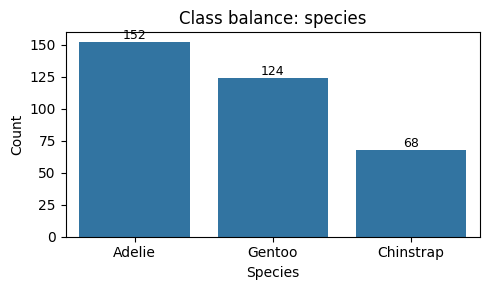

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
label = 'species'

# Basic cleaning: drop rows where species is missing
penguins = penguins.dropna(subset=[label]).copy()

# Show class balance
plt.figure(figsize=(5,3))
ax = sns.countplot(data=penguins, x=label, order=penguins[label].value_counts().index)
ax.set_title('Class balance: species')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Peek at columns
penguins.info()


In [7]:
penguins['body_mass_g']

0      3750.0
1      3800.0
2      3250.0
3         NaN
4      3450.0
        ...  
339       NaN
340    4850.0
341    5750.0
342    5200.0
343    5400.0
Name: body_mass_g, Length: 344, dtype: float64

### Features and label
We'll include both numeric and categorical columns. AutoGluon can infer types directly from the DataFrame.


In [8]:
# Separate features/label but keep in one DataFrame for AutoGluon (it expects label inside)
feature_cols = [c for c in penguins.columns if c != label]
penguins[feature_cols + [label]].head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species
0,Torgersen,39.1,18.7,181.0,3750.0,Male,Adelie
1,Torgersen,39.5,17.4,186.0,3800.0,Female,Adelie
2,Torgersen,40.3,18.0,195.0,3250.0,Female,Adelie
3,Torgersen,NaN,NaN,NaN,NaN,NaN,Adelie
4,Torgersen,36.7,19.3,193.0,3450.0,Female,Adelie


## 4) Create a **manual holdout** split (no scikit‑learn dependency)
### (aka: set-aside data)
We’ll randomly sample 20% for the test set using NumPy/pandas to avoid extra dependencies.
**Note:** This is for *final evaluation* only. It stays untouched during training.


In [11]:
TEST_SIZE = 0.3
n = len(penguins)
perm = np.random.permutation(n)
cut = int(n * (1 - TEST_SIZE))
train_idx, test_idx = perm[:cut], perm[cut:]

train_df = penguins.iloc[train_idx].reset_index(drop=True)
test_df  = penguins.iloc[test_idx].reset_index(drop=True)

train_df.shape, test_df.shape


((240, 7), (104, 7))

## 5) AutoGluon with **Holdout** (no CV / no bagging)
We fit on the training set with **default** settings (no stacking/bagging). AutoGluon will internally keep a small validation holdout for model selection. Then we evaluate on our **unseen** test set.


In [12]:
from pathlib import Path
import shutil  # windows version of rm -rf in unix

SAVE_PATH_HOLDOUT = Path('agModels-holdout')

# Safe, cross-platform cleanup
if SAVE_PATH_HOLDOUT.exists() and SAVE_PATH_HOLDOUT.is_dir():
    shutil.rmtree(SAVE_PATH_HOLDOUT)

predictor_holdout = TabularPredictor(label=label, path=str(SAVE_PATH_HOLDOUT)).fit(
    train_data=train_df,
    time_limit=TIME_LIMIT_SEC,
    # Consider specifying presets for stronger results:
    # presets='best_v150',  # or 'high_v150', 'best', etc.
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          8
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.37 GB / 15.99 GB (46.1%)
Disk Space Avail:   19.82 GB / 127.45 GB (15.6%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, TabDPT, and TabM. Requires a GPU and `pip install autogluon.tabular[tabarena]`

In [13]:
print('\nHoldout → Test evaluation:')
holdout_test_metrics = predictor_holdout.evaluate(test_df)

print('\nHoldout Leaderboard on Test:')
holdout_lb_test = predictor_holdout.leaderboard(test_df, silent=True)
holdout_lb_test.head()


Holdout → Test evaluation:

Holdout Leaderboard on Test:


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetTorch,1.000000,1.0,accuracy,0.011514,0.006000,0.893008,0.011514,0.006000,0.893008,1,True,10
1,WeightedEnsemble_L2,1.000000,1.0,accuracy,0.014513,0.007008,0.965240,0.003000,0.001008,0.072232,2,True,12
2,ExtraTreesEntr,1.000000,1.0,accuracy,0.081104,0.051508,0.680507,0.081104,0.051508,0.680507,1,True,8
3,NeuralNetFastAI,1.000000,1.0,accuracy,0.086751,0.013528,1.515248,0.086751,0.013528,1.515248,1,True,1
4,ExtraTreesGini,0.990385,1.0,accuracy,0.079297,0.052912,0.664759,0.079297,0.052912,0.664759,1,True,7


## 6) AutoGluon with **Cross‑Validation + Stacking/Bagging**
Now we enable CV by turning on bagging/stacking. We’ll use 5 folds and 1 stack level. AutoGluon trains models on folds, blends them, and often gains accuracy and stability.


In [14]:

SAVE_PATH_CV = Path('agModels-cv')     # You were missing this

# Clean up old directory if it exists
if SAVE_PATH_CV.exists() and SAVE_PATH_CV.is_dir():
    shutil.rmtree(SAVE_PATH_CV)

# ------------------------------------
# Train CV + Stacking model
# ------------------------------------
predictor_cv = TabularPredictor(
    label=label,
    path=str(SAVE_PATH_CV)
).fit(
    train_data=train_df,
    time_limit=TIME_LIMIT_SEC,
    auto_stack=True,        # enables bagging + stacking
    num_bag_folds=5,
    num_stack_levels=1,
)



Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          8
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.41 GB / 15.99 GB (46.3%)
Disk Space Avail:   19.81 GB / 127.45 GB (15.5%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, TabDPT, and TabM. Requires a GPU and `pip install autogluon.tabular[tabarena]`

In [ ]:
# ------------------------------------
# Evaluate
# ------------------------------------
print('\nCV → Test evaluation:')
cv_test_metrics = predictor_cv.evaluate(test_df)

print('\nCV Leaderboard on Test:')
cv_lb_test = predictor_cv.leaderboard(test_df, silent=True)
cv_lb_test.head()

## 7) Compare results (unseen test set)
We’ll line up key metrics from both approaches. (Exact numbers vary with randomness and time budget.)


In [ ]:
def extract_metric(metrics_dict, key_candidates):
    for k in key_candidates:
        if k in metrics_dict:
            return metrics_dict[k]
    return np.nan

rows = []
rows.append({
    'approach': 'Holdout (no CV)',
    'accuracy': extract_metric(holdout_test_metrics, ['accuracy']),
    'log_loss': extract_metric(holdout_test_metrics, ['log_loss']),
})
rows.append({
    'approach': 'CV + stacking (5 folds)',
    'accuracy': extract_metric(cv_test_metrics, ['accuracy']),
    'log_loss': extract_metric(cv_test_metrics, ['log_loss']),
})

cmp_df = pd.DataFrame(rows)
cmp_df


In [ ]:
# Simple bar chart for accuracy
plt.figure(figsize=(6,3.2))
ax = sns.barplot(data=cmp_df, x='approach', y='accuracy', hue='approach', palette=['#7aa6c2', '#4c78a8'], legend=False)
ax.set_ylim(0, 1)
ax.set_xlabel('')
ax.set_ylabel('Accuracy')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


### Confusion matrices
Confusion matrices on the same test set, using each trained predictor.


In [ ]:
from pandas import Categorical

def plot_confusion(predictor, test_df, title):
    y_true = test_df[label]
    y_pred = predictor.predict(test_df)
    labels = sorted(y_true.unique())
    cm = pd.crosstab(pd.Categorical(y_true, categories=labels), pd.Categorical(y_pred, categories=labels))

    plt.figure(figsize=(4.5,3.8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

plot_confusion(predictor_holdout, test_df, 'Holdout → Test Confusion')
plot_confusion(predictor_cv, test_df, 'CV + stacking (5 folds) → Test Confusion')


## 8) Takeaways and next steps
- For tabular data, **CV + stacking/bagging** in AutoGluon is a strong default.
- Keep a **separate, untouched test set** for final grading.
- Increase `TIME_LIMIT_SEC` or use `presets='best_quality'` for higher accuracy in longer labs.
- Explore `predictor_cv.leaderboard(test_df)` to inspect which base learners drive performance.

**Optional exercises**
1. Change `num_bag_folds` to 3 or 10 and observe accuracy changes.
2. Try adding `num_stack_levels=2` for deeper stacking.
3. Swap the target to a binary task (e.g., *Gentoo vs. not*) and compare metrics like F1.
